# Five-layer architecture: interface examples

This notebook is the executable usage guide for the modular architecture. The raw and standard data layers are implemented; later sections define the intended public interfaces.

## 1. Raw data layer

`RawDataManager` reads source metadata from a catalog, resolves paths under `data/`, and reports availability without interpreting source-specific columns. `source_id` is a stable dataset key, not a dynamically generated Python variable.

In [1]:
from pathlib import Path
import gc

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

from src.raw import RawDataManager
from src.standard import DATASET_IDS, StandardDataManager, time_bounds
from src.mapping import SpatiotemporalMappingManager
from src.case import PowerSystemCaseManager
from src.app import UnitCommitmentApplication

plt.ioff()  # Figures are shown only by an explicit display() call.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

project_root = Path.cwd()
data_root = project_root / "data"

In [3]:
raw_data = RawDataManager(project_root / "config/raw_data_sources.csv", data_root)
_catalog = raw_data._catalog
_check = raw_data.check()
_prepare = raw_data.prepare()
_source_id = "gem_integrated_power"
_file_path = raw_data.get_file(_source_id)

## 2. Standard data layer

`StandardDataManager` exposes the stable dataset IDs `spatial`, `network`, `generator`, `storage`, `parameter`, `load`, `population`, and `resource`. Source-specific processing is controlled by `config/standard_data.toml`; changing source dependencies does not change these public IDs.

In [4]:
standard_data = StandardDataManager(project_root / "config/standard_data.toml", raw_data=raw_data)
_check = standard_data.check()
# _build = standard_data.build()
_id = "parameter"
_sample = standard_data.load(_id)
_schema = _sample.schema

In [6]:
_para = standard_data.load("parameter")
_count = _para.count()
resolved, candidates = _para.resolve(
    standard_data.load("generator").iloc[10000],
    ["minimum_output_pu", "ramp_up_pu_per_hour"],
    dataset_id="generator",
    include_candidates=True
)
display(_count)
display(resolved)

,group,records,names,sources,datasets,classes,derived_records
0,technical,1317,86,4,3,15,49
1,economic,706,17,3,4,15,19
2,environmental,63,9,1,1,6,0
3,others,0,0,0,0,0,0


,target_uid,name,candidate_count,eligible_count,selected_parameter_uid,value,unit,match_rank,match_result,match_info,group,source_id,source_uid,source_version,reference_url,quality,observed_at
0,gem:G100000812986,minimum_output_pu,18,1,model_assumptions:utility_scale_solar:minimum_output_pu,0.0,p.u.,0,eligible,parameter_uids=model_assumptions:utility_scale_solar:minimum_output_pu,technical,model_assumptions,utility_scale_solar:minimum_output_pu,2026-08-04,<NA>,model_default,2026-08-04
1,gem:G100000812986,ramp_up_pu_per_hour,18,1,model_assumptions:utility_scale_solar:ramp_up_pu_per_hour,1.0,p.u./h,0,eligible,parameter_uids=model_assumptions:utility_scale_solar:ramp_up_pu_per_hour,technical,model_assumptions,utility_scale_solar:ramp_up_pu_per_hour,2026-08-04,<NA>,model_default,2026-08-04


## 3. Spatiotemporal mapping layer

`SpatiotemporalMappingManager` creates clipped standard cells, conservative load/resource remapping, the largest connected network, and explicit cell/bus relationships. Run `mapping.build()` to regenerate all outputs; this example only checks existing results.

In [7]:
mapping = SpatiotemporalMappingManager(project_root / "config/mapping.toml", standard_data)
_check = mapping.check()
# _build = mapping.build()
_id = "network"
_schema = mapping.schema(_id)
_sample = mapping.load(_id)

In [ ]:
# Use the same metric CRS for cell construction and plotting.
_plot_crs = mapping.options["metric_crs"]

# Plot mapped datasets in a deterministic order and close each displayed figure.
for _mapping_id in (
    "spatial",
    "population",
    "generator",
    "storage",
    "load",
    "resource",
    "network",
):
    _figures = mapping.plot(_mapping_id, year=2024, map_crs=_plot_crs)
    if not isinstance(_figures, dict):
        _figures = {_mapping_id: _figures}
    for _figure in _figures.values():
        display(_figure)
        plt.close(_figure)
del _sample, _figures, _figure
gc.collect()

## 4. System case layer

`PowerSystemCaseManager` filters and reconnects mapped data, resolves parameters, aggregates assets, aligns time series, and returns one backend-neutral `PowerSystemCase`. PyPSA conversion is an optional final adapter.

In [8]:
case_manager = PowerSystemCaseManager(project_root / "config/case.toml", mapped_data=mapping, standard_data=standard_data)
power_system_case = case_manager.build()
display(power_system_case.validation)

,check,component,name,status,value,detail,target,required
0,network_connectivity,network,largest_connected_graph,pass,1.000000,7628 buses and 8786 connections,NaN,NaN
1,time_alignment,timeseries,common_timestamps,pass,24.000000,1h in Asia/Shanghai,NaN,NaN
2,aggregation_limit,generator,clustered_unit_commitment,warning,4625.000000,"Class/subclass aggregation supports continuous ED/planning and clustered UC, not exact unit-level binary commitment.",NaN,NaN
3,backend_parameter_manifest,branch,branch_ac_r,fallback,0.996995,8294/8319 resolved as ohm/km; fallback=0.03; unit_mismatches=0; conflicting_assets=0,Line.r,True
4,backend_parameter_manifest,branch,branch_ac_x,fallback,0.996995,8294/8319 resolved as ohm/km; fallback=0.3; unit_mismatches=0; conflicting_assets=0,Line.x,True
5,backend_parameter_manifest,branch,branch_ac_b,fallback,0.996995,8294/8319 resolved as nF/km; fallback=0.0; unit_mismatches=0; conflicting_assets=0,Line.b,False
6,backend_parameter_manifest,branch,branch_ac_s_nom,fallback,0.996995,8294/8319 resolved as MVA/circuit; fallback=2000.0; unit_mismatches=0; conflicting_assets=0,Line.s_nom,True
7,backend_parameter_manifest,branch,branch_dc_p_nom,fallback,0.000000,0/2226 resolved as MVA/circuit; fallback=2000.0; unit_mismatches=0; conflicting_assets=0,Link.p_nom,True
8,backend_parameter_manifest,branch,branch_dc_efficiency,fallback,0.000000,0/2226 resolved as p.u.; fallback=1.0; unit_mismatches=0; conflicting_assets=0,Link.efficiency,False
9,backend_parameter_manifest,transformer,transformer_s_nom,fallback,0.000000,0/55 resolved as MVA; fallback=3000.0; unit_mismatches=0; conflicting_assets=0,Transformer.s_nom,True


In [27]:
dir(power_system_case)

['__annotations__',
 '__class__',
 '__dataclass_fields__',
 '__dataclass_params__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__match_args__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__replace__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'config',
 'generator',
 'load',
 'network',
 'parameter_manifest',
 'plot',
 'population',
 'resource',
 'spatial',
 'storage',
 'to_pypsa',
 'validation']

## 5. Case visualization

Case plots share the standard/mapping API and visual style. They return figures without displaying or saving them.

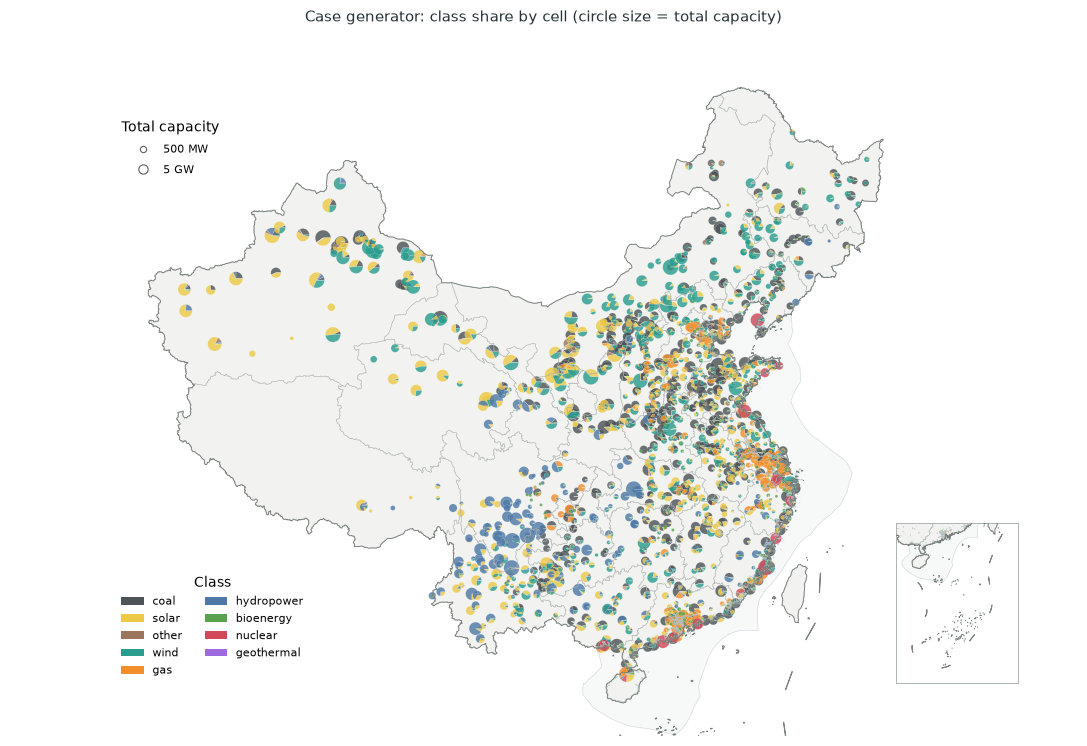

In [25]:
# Case, mapping, and standard layers expose the same core plot options.
_dataset_id = "generator"
_plot_options = {
    "start": "2024-07-15 00:00",  # Used by case load.
    "end": "2024-07-15 23:00",
    "map_crs": mapping.options["metric_crs"],
    "spatial_levels": None,      # All levels; e.g. ["province"] or ["marine_zone"].
    "china_inset": None,         # Automatic for China; False disables the inset.
}
_save_directory = None              # e.g. project_root / "outputs" / "figures"
_save_dpi = 300

_figures = power_system_case.plot(
    _dataset_id, spatial=standard_data.load("spatial"), **_plot_options
)
if not isinstance(_figures, dict):
    _figures = {_dataset_id: _figures}
for _name, _figure in _figures.items():
    display(_figure)
    if _save_directory is not None:
        _save_directory.mkdir(parents=True, exist_ok=True)
        _figure.savefig(
            _save_directory / f"{_dataset_id}_{_name}.png",
            dpi=_save_dpi,
            bbox_inches="tight",
        )
    plt.close(_figure)


## 6. Continuous UC/ED application

The current aggregated case uses continuous dispatch variables. The PyPSA application solves the selected period and returns a colored production-simulation figure.

/Users/jiang/Documents/Codex/nature-plan-paper/paper-codes/src/case/model.py:69: RuntimeWarning: PyPSA parameter coverage has 22 failed checks; inspect case.validation for component-level details.
  return to_pypsa(self, strict=strict)
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - time_limit: 300.0
 - mip_rel_gap: 0.01
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|████████████████████████████████████████████████████| 7/7 [00:00<00:00, 256.84it/s]
INFO:linopy.io: Writing time: 2.01s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 400248 primals, 1149308 duals
Objective: 1.19e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-p-ramp_limit_up, Generator-p-ramp_limit_down, Line-fix-s-lower, Line-fix-s-upper, Transformer-f

,value
solver_status,ok
termination_condition,optimal
is_optimal,True
objective,11941054477.995802
snapshots,24
load_mwh,28768534.852603
load_shedding_mwh,1128711.971729
load_shedding_share,0.039234
storage_discharge_mwh,65.0
storage_charge_mwh,65.0


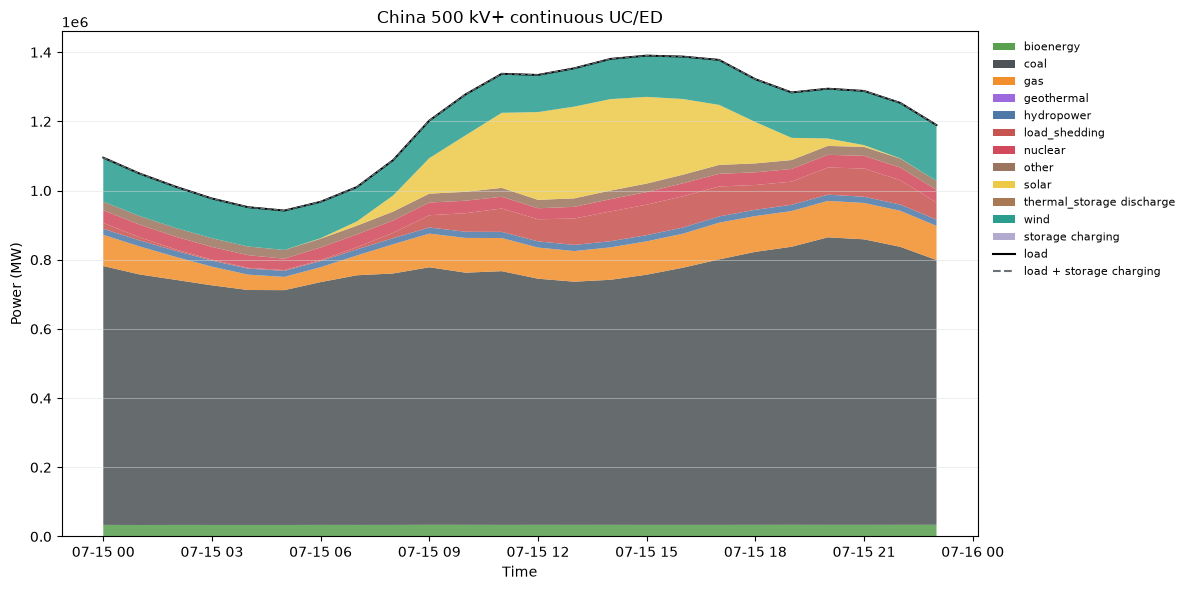

In [10]:
uc_application = UnitCommitmentApplication(
    power_system_case, project_root / "config/uc.toml"
)
uc_result = uc_application.run()
display(uc_result.summary.to_frame())

uc_figure = uc_result.plot(
    start="2024-07-15 00:00",
    end="2024-07-15 23:00",
    title="China 500 kV+ continuous UC/ED",
)
display(uc_figure)
plt.close(uc_figure)